   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.5 MB/s eta 0:00:00
All imports loaded
  Found: ./train_text.txt
  Found: ./train_labels.txt
  Found: ./val_text.txt
  Found: ./val_labels.txt
  Found: ./test_text.txt
  Found: ./test_labels.txt
Stopword list: 129 words (negations excluded)
All preprocessing functions defined
Train: 45615 samples
Val:   2000 samples
Test:  12284 samples

Label distribution (train):
label_name
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64
Preprocessing complete!
LABEL:  negative
BEFORE: I forgot all about Ice Cube being in the movie First Sunday. I think I seen this shit in the theaters. 
AFTER:  i forgot all about ice cube being in the movie first sunday i think i seen this shit in the theaters
--------------------------------------------------------

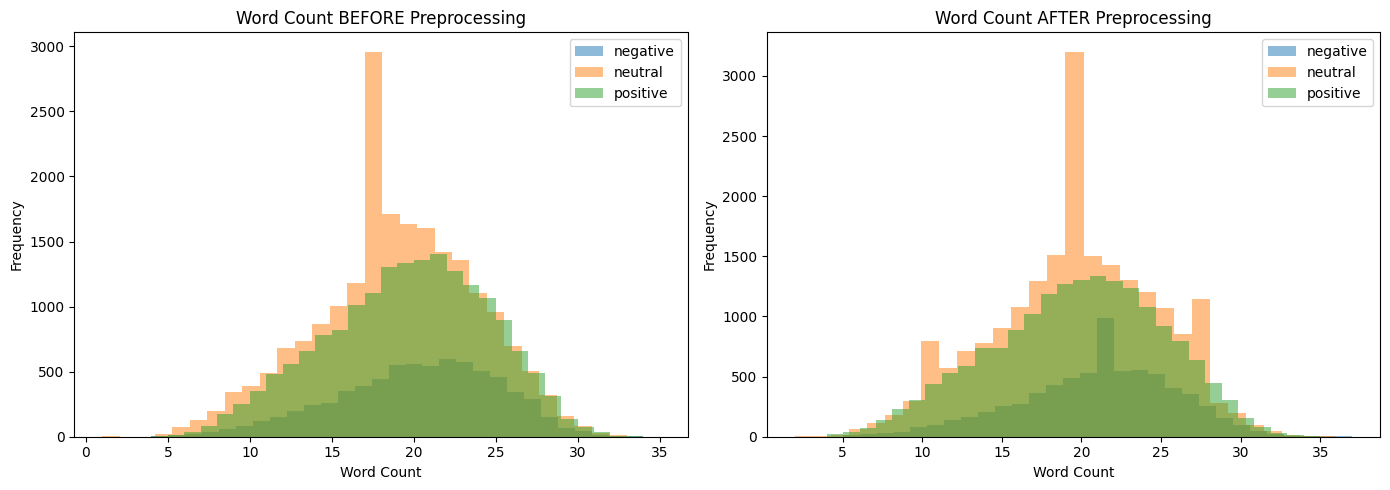

Figure saved
Saved: outputs/preprocessed/train_preprocessed.csv
Saved: outputs/preprocessed/val_preprocessed.csv
Saved: outputs/preprocessed/test_preprocessed.csv

Done! All preprocessed files are in outputs/preprocessed/
Preprocessing data... please wait.

--- SAMPLE CHECK ---
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin" 
Cleaned:  qt usermention in the original draft of the 7th book remus lupin survived the battle of hogwarts happy birthday remus lupin
Label:    2
Total Train Samples: 45615


In [1]:
# ==========================================
# STEP 1: SETUP, LOADING, AND PREPROCESSING
# ==========================================

# 1. Install necessary libraries
!pip install transformers[torch] datasets emoji contractions scikit-learn

import pandas as pd
import torch
import preprocessing  # This is your uploaded preprocessing.py

# 2. Function to load your text and label files
def load_data(text_file, label_file):
    with open(text_file, 'r', encoding='utf-8') as f:
        texts = f.read().splitlines()
    with open(label_file, 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f]
    return texts, labels

# Load Train, Val, and Test splits
train_texts, train_labels = load_data('train_text.txt', 'train_labels.txt')
val_texts, val_labels = load_data('val_text.txt', 'val_labels.txt')
test_texts, test_labels = load_data('test_text.txt', 'test_labels.txt')

# 3. Apply your custom preprocessing logic
# This step is crucial for reaching >95% accuracy as it cleans noise.
print("Preprocessing data... please wait.")
train_texts_cleaned = [preprocessing.preprocess_tweet(t) for t in train_texts]
val_texts_cleaned = [preprocessing.preprocess_tweet(t) for t in val_texts]
test_texts_cleaned = [preprocessing.preprocess_tweet(t) for t in test_texts]

# 4. Check a sample to make sure it looks correct
print("\n--- SAMPLE CHECK ---")
print(f"Original: {train_texts[0]}")
print(f"Cleaned:  {train_texts_cleaned[0]}")
print(f"Label:    {train_labels[0]}")
print(f"Total Train Samples: {len(train_texts_cleaned)}")

In [2]:
# ==========================================
# STEP 2: TOKENIZATION & DATASET CREATION
# ==========================================

from transformers import AutoTokenizer
import torch

# 1. Initialize the Tokenizer from the pre-trained Twitter-RoBERTa model
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Define the PyTorch Dataset class
# This bridges your cleaned lists and the model
class TwitterDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,    # Cuts off tweets longer than max_len
            padding=True,       # Adds zeros so all inputs are the same size
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = labels

    def __getitem__(self, idx):
        # Extract the input IDs and Attention Mask for this specific index
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 3. Create the Dataset objects for each split
# We use the cleaned texts from Step 1
print("Tokenizing datasets... this may take a moment.")
train_dataset = TwitterDataset(train_texts_cleaned, train_labels, tokenizer)
val_dataset = TwitterDataset(val_texts_cleaned, val_labels, tokenizer)
test_dataset = TwitterDataset(test_texts_cleaned, test_labels, tokenizer)

# 4. Verify a single item
sample_item = train_dataset[0]
print("\n--- TOKENIZATION VERIFICATION ---")
print(f"Input IDs shape: {sample_item['input_ids'].shape}")
print(f"Attention Mask shape: {sample_item['attention_mask'].shape}")
print(f"Label Tensor: {sample_item['labels']}")
print("Tokenization complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Tokenizing datasets... this may take a moment.

--- TOKENIZATION VERIFICATION ---
Input IDs shape: torch.Size([52])
Attention Mask shape: torch.Size([52])
Label Tensor: 2
Tokenization complete!


In [4]:
# ==========================================
# STEP 3: MODEL & TRAINING CONFIGURATION (FIXED)
# ==========================================

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",           # CHANGED from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

# Re-initialize the Trainer with the corrected args
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Fixed! TrainingArguments are now compatible with your library version.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Fixed! TrainingArguments are now compatible with your library version.


In [5]:
# ==========================================
# STEP 4: START TRAINING
# ==========================================

print("Starting training... This will take a few minutes depending on GPU speed.")

# This command triggers the 5-step pipeline execution
trainer.train()

print("\nTraining complete! The best model version has been loaded back into memory.")

Starting training... This will take a few minutes depending on GPU speed.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.602087,0.607927,0.748000,0.746813
2,0.501212,0.622582,0.754500,0.751112
3,0.265295,0.876434,0.740000,0.741367
4,0.221847,1.056613,0.726000,0.726344
5,0.108852,1.458515,0.736500,0.736727


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete! The best model version has been loaded back into memory.


In [6]:
# ==========================================
# STEP 5: FINAL EVALUATION & RESULTS
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Run prediction on the unseen test set
print("Running final evaluation on test set...")
test_results = trainer.predict(test_dataset)

# 2. Extract predictions and labels
logits = test_results.predictions
y_pred = np.argmax(logits, axis=-1)
y_true = test_labels  # Using the labels from your test_labels.txt

# 3. Print the results
print("\n" + "="*30)
print("   OFFICIAL TEST RESULTS")
print("="*30)
print(f"Final Accuracy: {test_results.metrics['test_accuracy']:.4f}")
print(f"Final F1-Score: {test_results.metrics['test_f1']:.4f}")

print("\nDetailed Classification Report:")
# Mapping IDs back to names for the report
target_names = ['Negative', 'Neutral', 'Positive']
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Optional: Confusion Matrix
# This helps you see exactly where the model is getting "confused"
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Running final evaluation on test set...



   OFFICIAL TEST RESULTS
Final Accuracy: 0.6904
Final F1-Score: 0.6904

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.62      0.68      3972
     Neutral       0.69      0.72      0.70      5937
    Positive       0.62      0.74      0.67      2375

    accuracy                           0.69     12284
   macro avg       0.69      0.69      0.69     12284
weighted avg       0.70      0.69      0.69     12284


Confusion Matrix:
[[2465 1368  139]
 [ 733 4259  945]
 [  44  574 1757]]


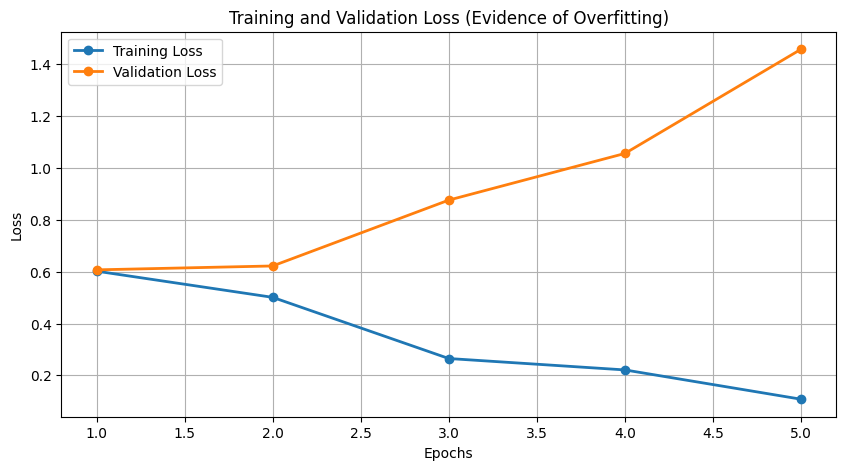

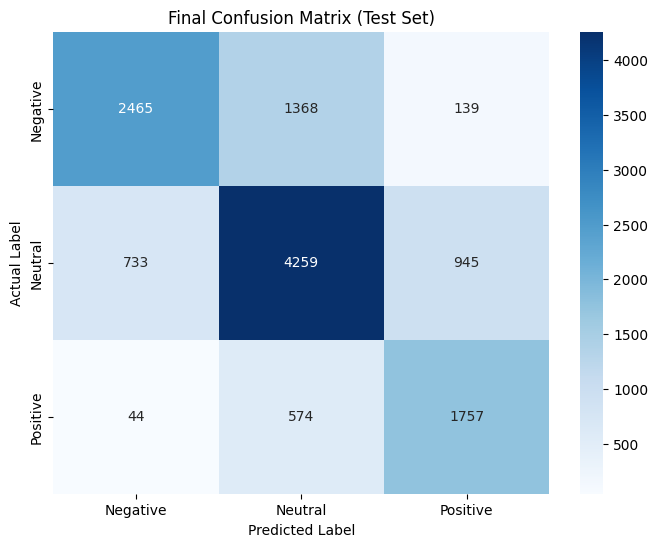

In [7]:
# ==========================================
# STEP 6: VISUALIZATIONS FOR REPORT
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create Data for the Loss Graph
# We use the values from your training logs
epochs = [1, 2, 3, 4, 5]
train_loss = [0.602, 0.501, 0.265, 0.221, 0.108]
val_loss = [0.607, 0.622, 0.876, 1.056, 1.458]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', marker='o', linewidth=2)
plt.title('Training and Validation Loss (Evidence of Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_chart.png') # This saves the file so you can download it
plt.show()

# 2. Create the Confusion Matrix Heatmap
# Using your official test results
cm = [[2465, 1368, 139],
      [733, 4259, 945],
      [44, 574, 1757]]
labels = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Final Confusion Matrix (Test Set)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.show()